## Experiment and Evaluate a Random Forest Regressor on data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('data/engineered_features_scaled.csv')

In [3]:
X = df.drop(columns='revenue')
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [26]:
n_estimators_list = [5, 20, 50, 100, 1000, 10000]
max_depth_list = [5, 10, 15, None]

results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=1,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)


        y_pred = rf.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        results.append({
            'n_estimators': n,
            'max_depth': depth,
            'r2': r2,
            'mse': mse
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by best R²
results_df = results_df.sort_values(by='r2', ascending=False)

print(results_df)

   n_estimators  max_depth        r2       mse
0         10000         15  0.502491  4.005446
1         20000         15  0.502485  4.005497
2         50000         15  0.502385  4.006301


In [22]:
## Best result, n_estimators = 10000, max_depth = 15

rf = RandomForestRegressor(
            n_estimators=10000,
            max_depth=15,
            random_state=1,
            n_jobs=-1
        )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

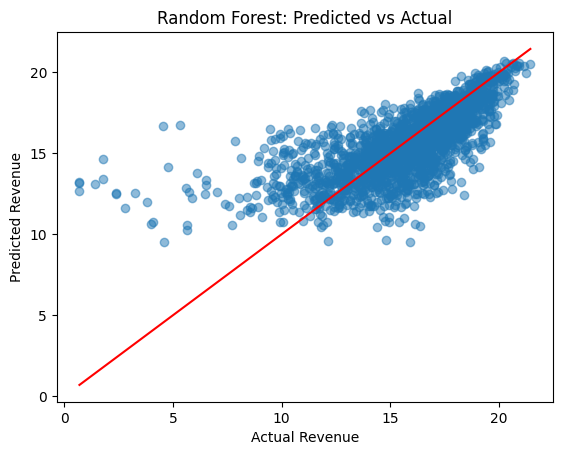

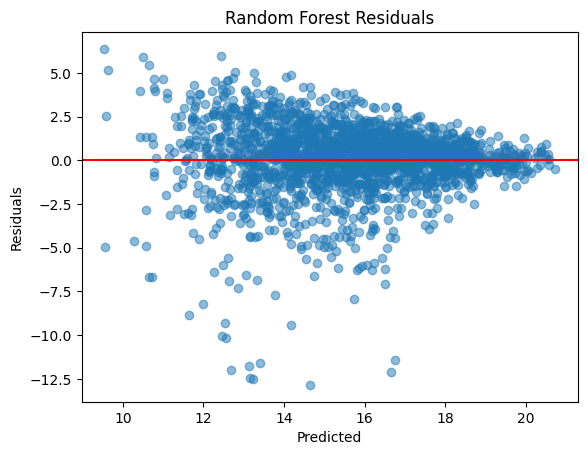

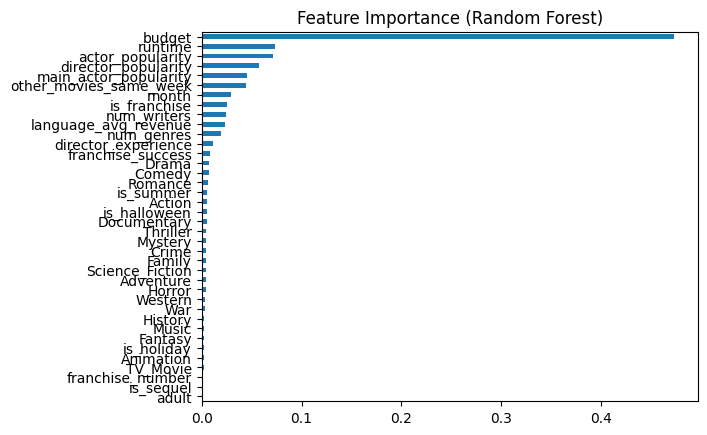

In [28]:
## Predicted vs Actual
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Random Forest: Predicted vs Actual")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red')

plt.show()

## Residual plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Random Forest Residuals")
plt.show()

## Feature importance
importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=X_train.columns)

feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()

In [24]:
## compare

model = Lasso()
model.fit(X_train, y_train)

y_pred_linear = model.predict(X_test)

False


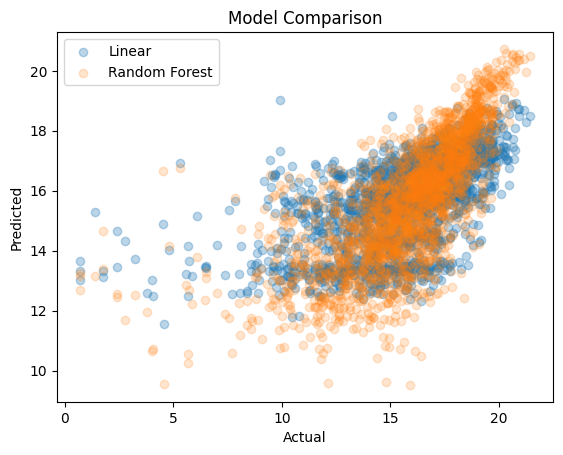

In [25]:
print((y_pred_linear == y_pred_rf).all())

plt.scatter(y_test, y_pred_linear, alpha=0.3, label='Linear')
plt.scatter(y_test, y_pred_rf, alpha=0.2, label='Random Forest')

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison")
plt.show()